# Evaluation of regression models

## Importing libraries and dataset

In [1]:
# Begin by importing necessary libraries to start this exercise

import numpy as np  # always useful for Scikit-learn
import pandas as pd # always usefull for data preparation
import matplotlib.pyplot as plt # if you want to plot something
import os.path      # work with files within this environment

# Check if the file was already downloaded, if so, remove it

from pathlib import Path
my_file = Path("test_regression.csv")
if my_file.is_file():
   os.unlink("test_regression.csv")

# download the file from github, use -q for quiet
# use --show-progress to show download progress only

!wget -q --show-progress https://raw.githubusercontent.com/coyoacan/Practice-in-Colab/refs/heads/main/source-files/test_regression.csv
dataset = pd.read_csv('test_regression.csv')

# See which kind of features we are dealing with

dataset.info()

test_regression.csv 100%[===================>] 310.80K  --.-KB/s    in 0.04s   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


## Plot independent variables

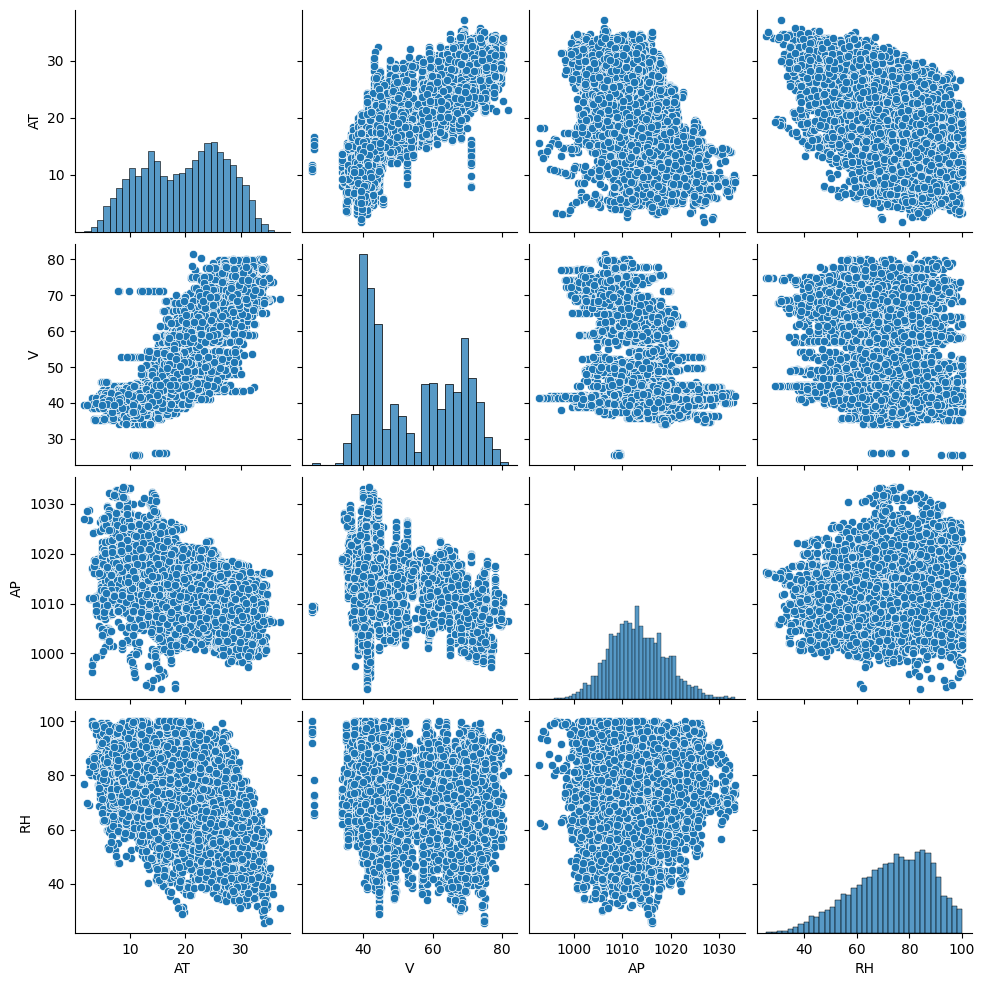

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

independent_variables_dataset = dataset.drop(columns=['PE'])

sns.pairplot(independent_variables_dataset)
plt.show()

## Separating X and y from the dataset

In [3]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [4]:
from sklearn.model_selection import train_test_split

## Decision Tree Regression: training, prediction and score

In [5]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
regressor.fit(X_train, y_train)

# Predict y values
y_pred = regressor.predict(X_test)

score_DecisionTreeRegressor = regressor.score(X_test, y_test)

print(score_DecisionTreeRegressor)

0.922905874177941


## Multiple linear regression: training, prediction and score

In [6]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
regressor.fit(X_train, y_train)

# Predict y values
y_pred = regressor.predict(X_test)

score_LinearRegression = regressor.score(X_test, y_test)

print(score_LinearRegression)

0.9325315554761303


## Polynomial regression: training, prediction and score

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# 4th degree polynomial equation
poly = PolynomialFeatures(degree=4, include_bias=False)

# Transform X_
poly_features = poly.fit_transform(X_train)

# Polynomial Regression Model
poly_reg_model = LinearRegression()
poly_reg_model.fit(poly_features, y_train)

# Predict y values (IMPORTANT: use polynomial features transform)
y_pred = poly_reg_model.predict(poly.transform(X_test))

#(IMPORTANT: use polynomial features transform)
score_PolyRegression= poly_reg_model.score(poly.transform(X_test),y_test)

print(score_PolyRegression)

0.9455261542481366


## Random forest regression: training, prediction and score

In [8]:
from sklearn.ensemble import RandomForestRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

randomforestreg = RandomForestRegressor(max_depth=2, random_state=0)
randomforestreg.fit(X_train, y_train)

# Predict y values
y_pred = randomforestreg.predict(X_test)

score_RandomForestRegression= randomforestreg.score(X_test,y_test)

print(score_PolyRegression)

0.9455261542481366


## Support vector regression: training, prediction and score

In [9]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

SVRregressor = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2, kernel='rbf'))
SVRregressor.fit(X_train, y_train)

# Predict y values
y_pred = SVRregressor.predict(X_test)

score_SVR= SVRregressor.score(X_test,y_test)

print(score_SVR)

0.9430592276377037


## Report R scores for each regression approach

In [10]:
from prettytable import PrettyTable

# specify the Column Names while initializing the Table
table = PrettyTable(["Regression Method", "R squared score"])

# add rows
table.add_row(["Random Forest Regression", f"{score_RandomForestRegression:.4f}"])
table.add_row(["Polynomial Regression", f"{score_PolyRegression:.4f}"])
table.add_row(["Multiple Linear Regression", f"{score_LinearRegression:.4f}"])
table.add_row(["Decision Tree", f"{score_DecisionTreeRegressor:.4f}"])
table.add_row(["Support Vector", f"{score_SVR:.4f}"])

print(table)

+----------------------------+-----------------+
|     Regression Method      | R squared score |
+----------------------------+-----------------+
|  Random Forest Regression  |      0.8831     |
|   Polynomial Regression    |      0.9455     |
| Multiple Linear Regression |      0.9325     |
|       Decision Tree        |      0.9229     |
|       Support Vector       |      0.9431     |
+----------------------------+-----------------+
